# Importing libraries

In [1]:
import re
import nltk
import pickle
import gensim
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from nltk import sent_tokenize
import gensim.downloader as api
from nltk.corpus import stopwords
from matplotlib import pyplot as plt
from nltk.stem import WordNetLemmatizer
from gensim.utils import simple_preprocess #simple_preprocess lowers each word
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

### Loading the dataset

In [4]:
issues_df = pd.read_csv('/content/sample1.csv')

# EDA

In [5]:
issues_df.shape

(72289, 7)

In [6]:
#Checking null values
issues_df.isnull().sum()

,0
issue_url,0
issue_label,0
issue_created_at,0
issue_author_association,0
repository_url,0
issue_title,0
issue_body,7148


In [7]:
#Drop null Values
issues_df.dropna(inplace=True)

In [8]:
issues_df.reset_index(drop=True,inplace=True)

In [9]:
issues_df.sample(5)

,issue_url,issue_label,issue_created_at,issue_author_association,repository_url,issue_title,issue_body
34135,https://api.github.com/repos/gwonhong/21s_fina...,enhancement,2021-05-09T10:29:43Z,OWNER,https://api.github.com/repos/gwonhong/21s_fina...,index에 구현해야할 것,- [x] 게임 시작 버튼\r\n- [x] 게임 종료 버튼\r\n- [x] 기록 확...
57030,https://api.github.com/repos/fisherab/store-sc...,enhancement,2021-03-13T16:51:50Z,OWNER,https://api.github.com/repos/fisherab/store-sc...,Avoid confusion between two competitions on on...,If two blocks are displayed on same page and a...
12440,https://api.github.com/repos/hannahhch/will-an...,bug,2021-03-28T20:18:40Z,OWNER,https://api.github.com/repos/hannahhch/will-an...,Test issue,Test
3769,https://api.github.com/repos/sourcegraph/sourc...,bug,2020-12-14T13:33:33Z,MEMBER,https://api.github.com/repos/sourcegraph/sourc...,Code monitors page info is wrong at end of list,When looking at the list of 1 code monitors I ...
57296,https://api.github.com/repos/lectra-tech/koson...,enhancement,2021-03-30T12:20:00Z,NONE,https://api.github.com/repos/lectra-tech/koson,Allow adding nullable objects,**Describe the solution you'd like**\r\nI want...


In [10]:
#Considering only the useful columns from the dataframe
issues_df=issues_df[['issue_title','issue_body','issue_label']]
issues_df

,issue_title,issue_body,issue_label
0,__tileSrcRect is null in Entities.ldtk Sample ...,"In the Entities example, we there are some `__...",bug
1,Update the blog link in the SEF Site,**Describe the bug**\r\nUpdate the blog link i...,bug
2,🐛 Parser cannot properly distinguish between p...,Consider these two expressions:\r\n```\r\nf (g...,bug
3,"""Row added"" snackbar is not visible if the gri...",## Description \r\nWhen grid has no height an...,bug
4,[CRASH] _tcp_write_on_socket crashes when flu...,<!--\r\nThank you for reporting a crash in Ope...,bug
...,...,...,...
65136,[HELP] Volume Mount hostpath: Unable to mount ...,hi Team I am facing the below issue. Any solut...,question
65137,is form.progress valid for upload progress?,I thought form.progress would get fired every ...,question
65138,"RPi used for door contact sensors, warning in log",Thank you for the most excellent plug-in!! \r\...,question
65139,Tail latency of envoy proxy is bad if every re...,We have envoy running as the front door servic...,question


In [11]:
# finding the unique issue labels
issues_df['issue_label'].unique()

array(['bug', 'enhancement', 'question'], dtype=object)

## Checking frequencies of each category

In [12]:
issue_label_counts_df = issues_df.issue_label.value_counts().reset_index()
issue_label_counts_df.columns = ['issue_label', 'count']

print(issue_label_counts_df)

   issue_label  count
0          bug  33745
1  enhancement  25295
2     question   6101


Text(0.5, 0, 'Frequency ')

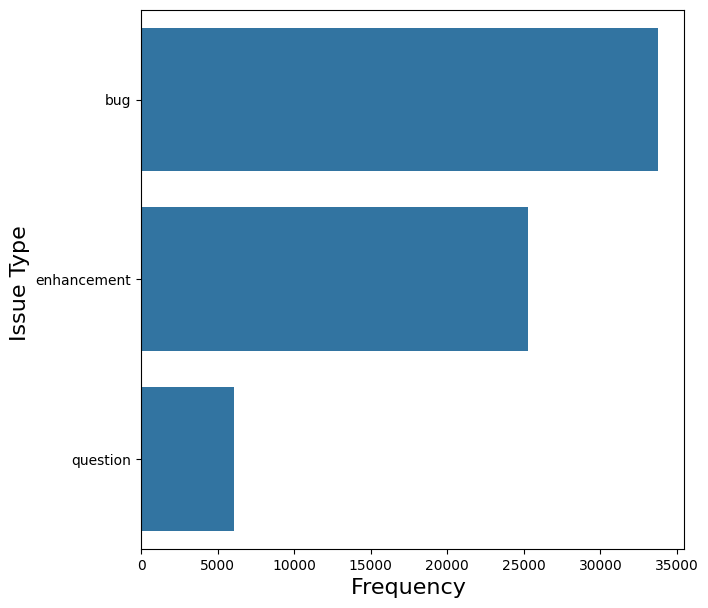

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

sns.barplot(data=issue_label_counts_df,
            x='count',
            y='issue_label',
            dodge=False,
            ax=ax)

plt.ylabel("Issue Type ",fontsize=16)
plt.xlabel("Frequency ",fontsize=16)

# Data cleaning and preprocessing


In [21]:
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('wordnet2022')
nltk.download('stopwords')
lemmatizer=WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package wordnet2022 to /root/nltk_data...
[nltk_data]   Package wordnet2022 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Combining columns issue_title and issue_body

In [15]:
issues = [row.issue_title+' '+row.issue_body for index, row in issues_df.iterrows()]

### Tokenization, Removing Stop words and Lemmatization

In [16]:
#Remove special characters, remove stopwords and lemmatize and store as corpus
corpus = []
for issue in tqdm(issues):
    i = re.sub('[^a-zA-Z?!]', ' ', issue)#convert every non alphabetical character to blank space
    i = i.lower()
    i = i.split()

    #apply lemmatization to words which are not stopwords
    i = [lemmatizer.lemmatize(word) for word in i if not word in stopwords.words('english')]
    i = ' '.join(i)
    corpus.append(i)

100%|██████████| 65141/65141 [20:56<00:00, 51.84it/s]


### Save corpus

In [17]:
with open("/content/corpus.bin", "wb") as output:
    pickle.dump(corpus, output)

### Load corpus

In [18]:
corpus= pd.read_pickle(r'/content/corpus.bin')

In [19]:
corpus

['tilesrcrect null entity ldtk sample nullable according json schema entity example tilesrcrect field null http github com deepnight ldtk blob ec b f b b e baca app sample entity ldtk l l according schema field required http github com deepnight ldtk blob ec b f b b e baca doc json schema json l l rust crate failed validate entity sample difference turn rust crate make good test case schema smile',
 'update blog link sef site describe bug update blog link entire website new link http sefglobal medium com please find blog page access place following place navigation bar footer expected behavior blog hyperlink redirected medium sef channel',
 'parser cannot properly distinguish parenthesised expression multiple argument consider two expression f g x f g x first expression say f function called single argument result evaluating g x javascript would f g x second expression f function two argument g x javascript would f g x obviously two expression different attempting parse produce ast elm

### Tokenize words

In [22]:
words=[]#words present in each and every sentences
for sent in tqdm(corpus):
    sent_token=sent_tokenize(sent) # sent_tokenize splits paragraphs into sentences
    for sen in sent_token:
        words.append(simple_preprocess(sen)) #simple_preprocess tokenizes each word

100%|██████████| 65141/65141 [00:16<00:00, 3909.94it/s]


In [23]:
print(words[:2])

[['tilesrcrect', 'null', 'entity', 'ldtk', 'sample', 'nullable', 'according', 'json', 'schema', 'entity', 'example', 'tilesrcrect', 'field', 'null', 'http', 'github', 'com', 'deepnight', 'ldtk', 'blob', 'ec', 'baca', 'app', 'sample', 'entity', 'ldtk', 'according', 'schema', 'field', 'required', 'http', 'github', 'com', 'deepnight', 'ldtk', 'blob', 'ec', 'baca', 'doc', 'json', 'schema', 'json', 'rust', 'crate', 'failed', 'validate', 'entity', 'sample', 'difference', 'turn', 'rust', 'crate', 'make', 'good', 'test', 'case', 'schema', 'smile'], ['update', 'blog', 'link', 'sef', 'site', 'describe', 'bug', 'update', 'blog', 'link', 'entire', 'website', 'new', 'link', 'http', 'sefglobal', 'medium', 'com', 'please', 'find', 'blog', 'page', 'access', 'place', 'following', 'place', 'navigation', 'bar', 'footer', 'expected', 'behavior', 'blog', 'hyperlink', 'redirected', 'medium', 'sef', 'channel']]


# Training Word2Vec from scratch


In [24]:
model=gensim.models.Word2Vec(words,window=10,min_count=2,epochs=20)

In [25]:
#Save the model
model.save("/content/word2vec.model")

In [26]:
#Load the model
model = gensim.models.Word2Vec.load("/content/word2vec.model")

In [27]:
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [30]:
# model.wv.index_to_key

model.corpus_count

# model.epochs

136636

In [34]:
model.wv['work'].shape

(100,)

In [33]:
model.wv.similar_by_word('work')

[('working', 0.8213176131248474),
 ('worked', 0.7474636435508728),
 ('everything', 0.7350150346755981),
 ('however', 0.6302086114883423),
 ('grained', 0.6153145432472229),
 ('seem', 0.5789732336997986),
 ('unfortunately', 0.5426710844039917),
 ('perfectly', 0.5390045642852783),
 ('using', 0.5273739695549011),
 ('fine', 0.5019795298576355)]

# Converting Words to Vectors

In [35]:
def avg_word2vec(doc):
    # remove out-of-vocabulary words
    return np.mean([model.wv[word] for word in doc if word in model.wv.index_to_key],axis=0)

### Applying AvgerageWord2Vec for the entire sentences


In [36]:
X=[avg_word2vec(word) for word in tqdm(words)]

  0%|          | 18/136636 [00:00<22:06, 102.96it/s]/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 136636/136636 [14:09<00:00, 160.93it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (136636,) + inhomogeneous part.

In [37]:
X = np.asarray(X, dtype="object")

In [38]:
np.save('/content/X.npy', X) # save
# X = np.load('/content/X.npy') # load

In [39]:
X.shape

(136636,)

# One hot encoding for the labels

In [40]:
y=pd.get_dummies(issues_df['issue_label'])
y=y.iloc[:,1].values

In [42]:
y[0]

False

### Split dataset into training, testing and validation sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

# Creating a Random Forest Classifier

In [ ]:
classifier=RandomForestClassifier()

In [ ]:
#Training the RFclassifier
classifier.fit(X_train,y_train)

In [ ]:
#predictions for the test data
y_pred=classifier.predict(X_test)

### Getting accuracy and classification report

In [ ]:
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

# Making predictions